**MAJOR PROJECT**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


*Data Loading*

In [14]:
df = pd.read_csv('/content/Retail_Sales_Data_Unlox (1).csv')
print(df.shape)
print(df.columns)
print(df.dtypes)
df.head()

(73000, 19)
Index(['Date', 'Store_ID', 'Store_Location', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Units_Sold',
       'Total_Sales', 'Discount_Percentage', 'Revenue', 'Customer_Type',
       'Payment_Mode', 'Promotion_Applied', 'Stock_On_Hand', 'Store_Rating',
       'Region', 'Holiday_Flag'],
      dtype='object')
Date                    object
Store_ID                object
Store_Location          object
Product_ID              object
Product_Category        object
Product_Subcategory     object
Brand                   object
Unit_Price             float64
Units_Sold               int64
Total_Sales            float64
Discount_Percentage      int64
Revenue                float64
Customer_Type           object
Payment_Mode            object
Promotion_Applied       object
Stock_On_Hand            int64
Store_Rating           float64
Region                  object
Holiday_Flag             int64
dtype: object


,Date,Store_ID,Store_Location,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Units_Sold,Total_Sales,Discount_Percentage,Revenue,Customer_Type,Payment_Mode,Promotion_Applied,Stock_On_Hand,Store_Rating,Region,Holiday_Flag
0,2023-04-13,STR_104,Chennai,PRD_072,Sports,Athletics,Reebok,29973.06,39,1168949.34,5,1.110502e+06,Returning,Debit Card,Yes,422,4.4,South,0
1,2024-10-25,STR_103,Delhi,PRD_492,Sports,Outdoor,Yonex,46933.78,2,93867.56,15,7.978743e+04,Returning,UPI,No,302,4.1,North,0
2,2023-02-28,STR_107,Kolkata,PRD_958,Groceries,Household,Nestle,39280.28,44,1728332.32,15,1.469082e+06,Returning,Cash,No,184,3.8,East,0
3,2023-06-16,STR_102,Bangalore,PRD_014,Home Appliances,Kitchen,Whirlpool,40439.03,9,363951.27,5,3.457537e+05,New,UPI,Yes,493,3.7,South,0
4,2024-05-23,STR_108,Ahmedabad,PRD_932,Fashion,Women Clothing,Puma,9193.58,4,36774.32,5,3.493560e+04,Returning,Credit Card,No,359,3.5,West,0


In [15]:
from datetime import date
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['YearMonth'] = df['Date'].dt.to_period('M')

print(df.isnull().sum())

Date                   0
Store_ID               0
Store_Location         0
Product_ID             0
Product_Category       0
Product_Subcategory    0
Brand                  0
Unit_Price             0
Units_Sold             0
Total_Sales            0
Discount_Percentage    0
Revenue                0
Customer_Type          0
Payment_Mode           0
Promotion_Applied      0
Stock_On_Hand          0
Store_Rating           0
Region                 0
Holiday_Flag           0
Year                   0
Month                  0
Month_Name             0
YearMonth              0
dtype: int64


*Exploratory data analysis*

In [16]:
print(df.describe())
print("\nUnique stores:", df['Store_ID'].nunique())
print("Unique categories:", df['Product_Category'].unique())
print("Data range:", df['Date'].min(), "to", df['Date'].max())

                                Date    Unit_Price    Units_Sold  \
count                          73000  73000.000000  73000.000000   
mean   2023-12-31 11:52:59.835616256  25110.208554     24.894589   
min              2023-01-01 00:00:00    100.110000      1.000000   
25%              2023-07-03 00:00:00  12728.855000     13.000000   
50%              2023-12-31 00:00:00  25071.800000     25.000000   
75%              2024-06-30 00:00:00  37557.337500     37.000000   
max              2024-12-31 00:00:00  49999.850000     49.000000   
std                              NaN  14393.607981     14.134824   

        Total_Sales  Discount_Percentage       Revenue  Stock_On_Hand  \
count  7.300000e+04         73000.000000  7.300000e+04   73000.000000   
mean   6.261382e+05            10.010411  5.634765e+05     274.624712   
min    1.447000e+02             0.000000  1.229950e+02      50.000000   
25%    1.759852e+05             5.000000  1.575377e+05     162.000000   
50%    4.713577e+05   

Product_Category
Electronics        8.318539e+09
Home Appliances    8.262751e+09
Fashion            8.215645e+09
Groceries          8.170528e+09
Sports             8.166319e+09
Name: Revenue, dtype: float64


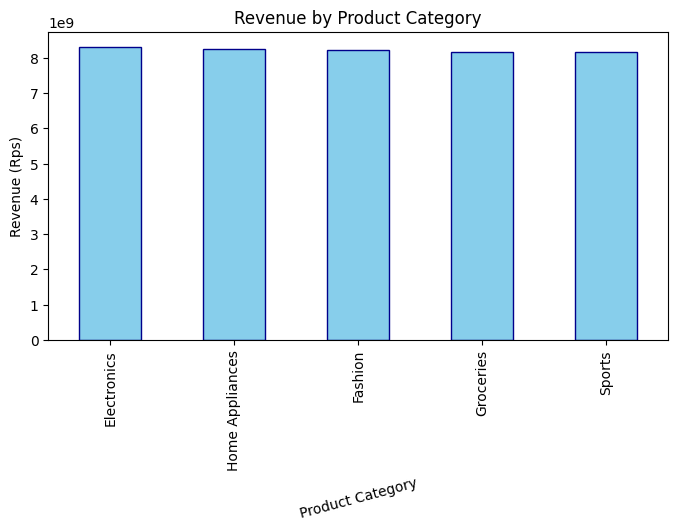

In [18]:
data = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending= False)
print(data)

data.plot(kind='bar', figsize=(8,4), color='skyblue', edgecolor='darkblue')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category', rotation=15)
plt.ylabel('Revenue (Rps)')
plt.show()

Store_ID  Store_Location
STR_103   Delhi             5.223064e+09
STR_102   Bangalore         5.186277e+09
STR_101   Mumbai            5.169675e+09
STR_104   Chennai           5.165937e+09
STR_105   Pune              5.161899e+09
STR_107   Kolkata           5.107832e+09
STR_108   Ahmedabad         5.078322e+09
STR_106   Hyderabad         5.040776e+09
Name: Revenue, dtype: float64
Region
West     1.540990e+10
South    1.539299e+10
North    5.223064e+09
East     5.107832e+09
Name: Revenue, dtype: float64


<Axes: xlabel='Region'>

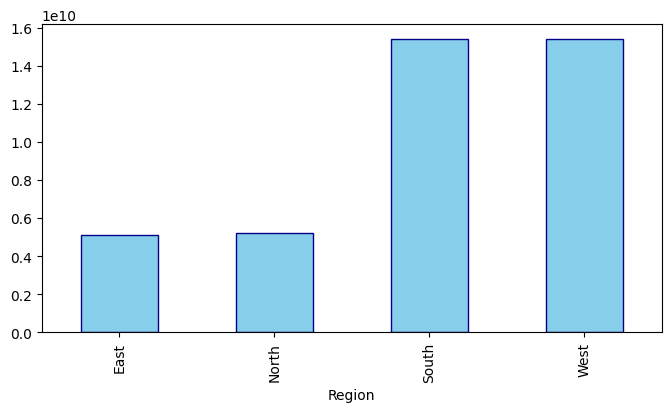

In [21]:
store_rev = df.groupby(['Store_ID','Store_Location'])['Revenue'].sum()
print(store_rev.sort_values(ascending=False))

region_rev = df.groupby('Region')['Revenue'].sum()
print(region_rev.sort_values(ascending=False))
region_rev.plot(kind='bar', figsize=(8,4), color='skyblue', edgecolor='darkblue')

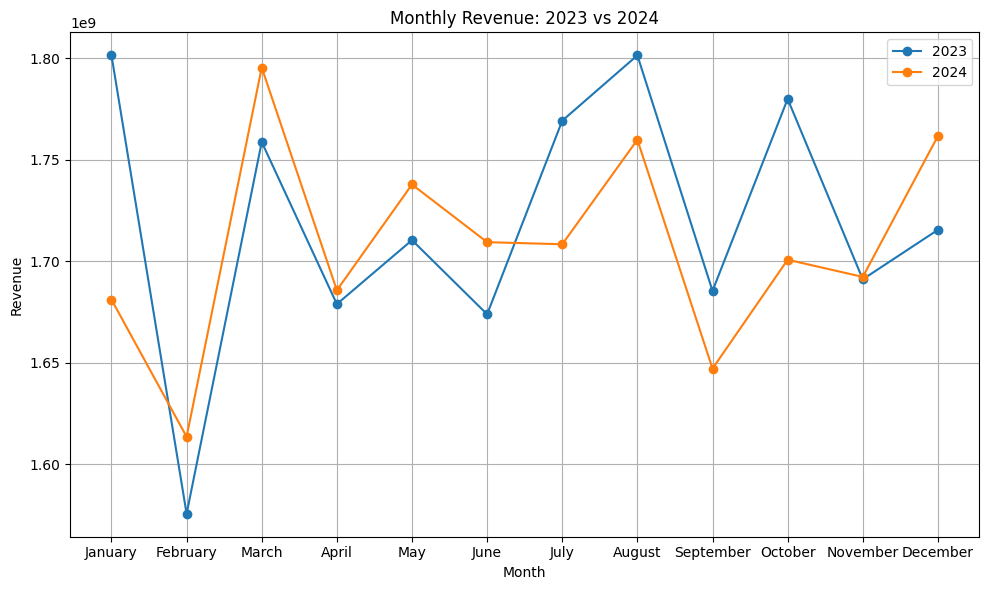

In [26]:
monthly = df.groupby(['Year', 'Month', 'Month_Name'])['Revenue'].sum().reset_index()

plt.figure(figsize=(10, 6))
for year in [2023, 2024]:
  data_year = monthly[monthly['Year'] == year]
  data_year = data_year.sort_values(by='Month')
  plt.plot(data_year['Month_Name'], data_year['Revenue'], marker="o", label=str(year))

plt.title('Monthly Revenue: 2023 vs 2024')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
promo = df.groupby('Promotion_Applied')['Revenue'].mean()
print("Avge revenue with promo:",promo)

cust = df.groupby('Customer_Type')['Revenue'].sum()
print("Revenue by customer type:",cust)

payment = df.groupby('Payment_Mode')['Revenue'].sum()
print("Revenue by payment method:",payment)

Avge revenue with promo: Promotion_Applied
No     563966.657885
Yes    562328.909666
Name: Revenue, dtype: float64
Revenue by customer type: Customer_Type
New          1.649363e+10
Returning    2.464015e+10
Name: Revenue, dtype: float64
Revenue by payment method: Payment_Mode
Cash           1.027046e+10
Credit Card    1.040749e+10
Debit Card     1.025743e+10
UPI            1.019840e+10
Name: Revenue, dtype: float64


*Sales patter and trend analysis*

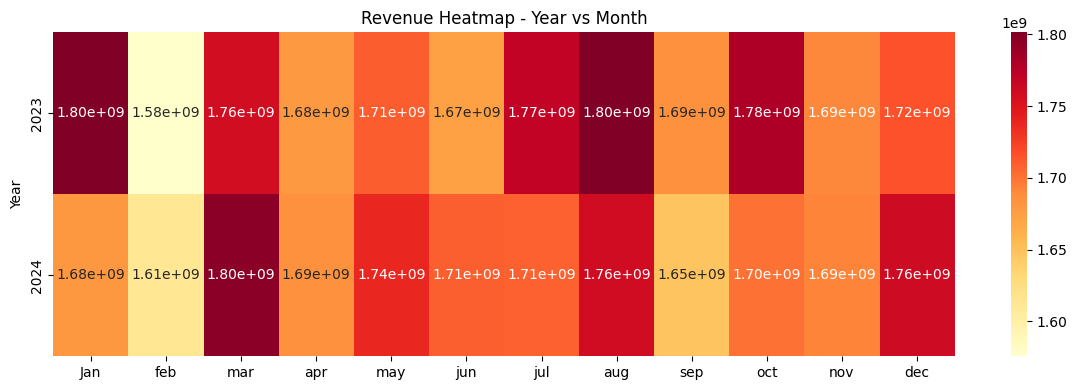

In [38]:
pivot = df.groupby(['Year','Month'])['Revenue'].sum().unstack()
pivot.columns = ['Jan',"feb",'mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
plt.figure(figsize=(12,4))
sns.heatmap(pivot, annot=True, fmt='.2e',cmap='YlOrRd')
plt.title('Revenue Heatmap - Year vs Month')
plt.tight_layout()
plt.show()

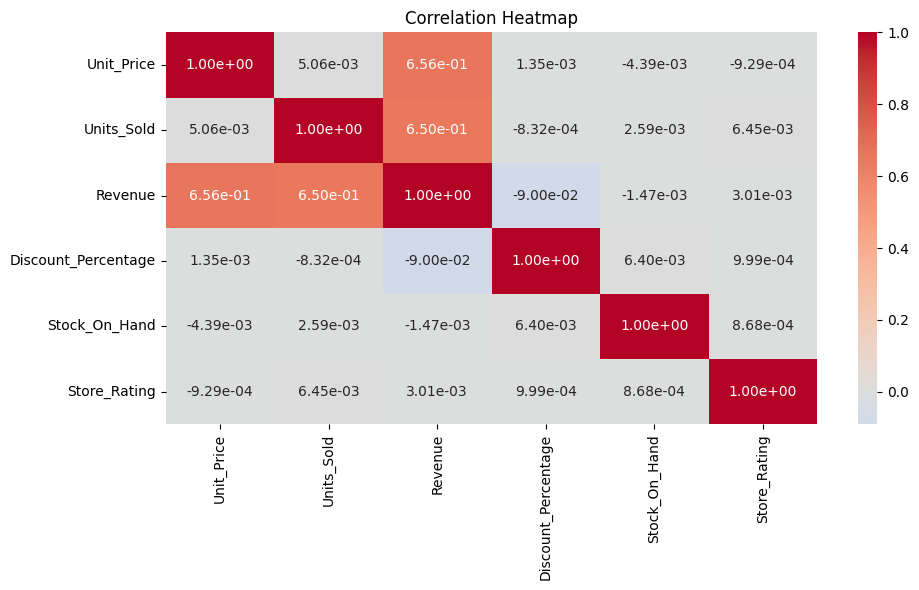

In [41]:
numeric_cols = ['Unit_Price','Units_Sold','Revenue','Discount_Percentage','Stock_On_Hand','Store_Rating']

corr = df[numeric_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True,fmt='.2e',cmap='coolwarm',center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

*Sales forecasting*

                 Revenue
YearMonth               
2023-01-01  1.801385e+09
2023-02-01  1.575642e+09
2023-03-01  1.758672e+09
2023-04-01  1.678882e+09
2023-05-01  1.710369e+09
2023-06-01  1.673871e+09
2023-07-01  1.769177e+09
2023-08-01  1.801351e+09
2023-09-01  1.685368e+09
2023-10-01  1.779866e+09
2023-11-01  1.691084e+09
2023-12-01  1.715440e+09
2024-01-01  1.681103e+09
2024-02-01  1.613559e+09
2024-03-01  1.795332e+09
2024-04-01  1.685703e+09
2024-05-01  1.737768e+09
2024-06-01  1.709369e+09
2024-07-01  1.708338e+09
2024-08-01  1.759781e+09
2024-09-01  1.647125e+09
2024-10-01  1.700723e+09
2024-11-01  1.692265e+09
2024-12-01  1.761612e+09


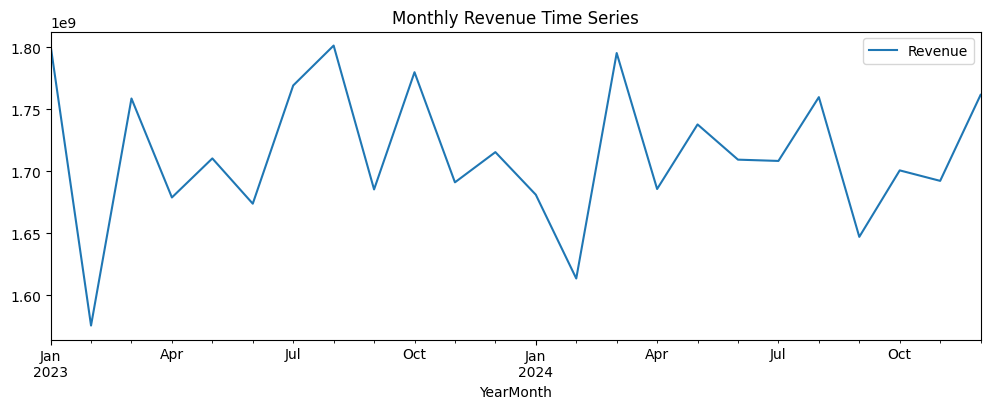

In [42]:
monthly_ts = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_ts['YearMonth'] = monthly_ts['YearMonth'].dt.to_timestamp()
monthly_ts = monthly_ts.set_index('YearMonth')
monthly_ts = monthly_ts.sort_index()
print(monthly_ts)
monthly_ts.plot(figsize=(12,4), title='Monthly Revenue Time Series')
plt.show()

In [46]:
from sklearn.linear_model import LinearRegression

monthly_ts['t']=range(len(monthly_ts))
X = monthly_ts[['t']]
y = monthly_ts['Revenue']

model = LinearRegression()
model.fit(X,y)
monthly_ts['Predicted'] = model.predict(X)

#forecast 12 months ahead

future = range(len(monthly_ts),len(monthly_ts)+12)
forecast_2025 = model.predict([[t] for t in future])
print("2025 Forecast totaly: Rps", round(sum(forecast_2025/1e9), 2), "Billion")

2025 Forecast totaly: Rps 20.54 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

#comparing predictions on 2023 -2024vs actual

fitted = monthly_ts['Predicted']
mae=mean_absolute_error(monthly_ts['Revenue'], fitted)
rmse=np.sqrt(mean_squared_error(monthly_ts['Revenue'], fitted))
mape= np.mean(np.abs((monthly_ts['Revenue']-fitted)/monthly_ts['Revenue']))*100

print(f"MAE: {mae:.0f}")
print(f"RMSE: {rmse:.0f}")
print(f"MAPE: {mape:.2f}%")

MAE: 45011846
RMSE: 56515175
MAPE: 2.64%


*Store segmentation*


In [54]:
store_features = df.groupby('Store_ID').agg(
    total_revenue=('Revenue', 'sum'),
    avg_units_sold=('Units_Sold', 'mean'),
    avg_discount=('Discount_Percentage', 'mean'),
    avg_rating=('Store_Rating', 'mean'),
    promo_rate = ('Promotion_Applied', lambda x: (x == 'Yes').mean()),
    returning_rate = ('Customer_Type', lambda x: (x == 'Returning').mean())
).reset_index()

print(store_features
)

  Store_ID  total_revenue  avg_units_sold  avg_discount  avg_rating  \
0  STR_101   5.169675e+09       25.076889     10.091824    4.250183   
1  STR_102   5.186277e+09       24.894702      9.998365    4.250981   
2  STR_103   5.223064e+09       25.016352      9.968931    4.250714   
3  STR_104   5.165937e+09       24.883518     10.113760    4.250501   
4  STR_105   5.161899e+09       24.607197     10.076724    4.245418   
5  STR_106   5.040776e+09       24.748613      9.944531    4.249467   
6  STR_107   5.107832e+09       25.109785      9.951839    4.248172   
7  STR_108   5.078322e+09       24.822030      9.935173    4.249978   

   promo_rate  returning_rate  
0    0.295940        0.601836  
1    0.300850        0.591236  
2    0.295105        0.593372  
3    0.295885        0.608208  
4    0.304517        0.603091  
5    0.301087        0.600510  
6    0.302320        0.606064  
7    0.298648        0.593639  


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


features = ['total_revenue', 'avg_units_sold', 'avg_discount', 'avg_rating', 'promo_rate', 'returning_rate']
scalar = StandardScaler()
scaled_features = scalar.fit_transform(store_features[features])
kmeans = KMeans(n_clusters=3, random_state=42)
store_features['Cluster'] = kmeans.fit_predict(scaled_features)

print(store_features[['Store_ID','total_revenue','avg_rating','Cluster']])

  Store_ID  total_revenue  avg_rating  Cluster
0  STR_101   5.169675e+09    4.250183        2
1  STR_102   5.186277e+09    4.250981        0
2  STR_103   5.223064e+09    4.250714        0
3  STR_104   5.165937e+09    4.250501        2
4  STR_105   5.161899e+09    4.245418        1
5  STR_106   5.040776e+09    4.249467        1
6  STR_107   5.107832e+09    4.248172        1
7  STR_108   5.078322e+09    4.249978        1


Text(0.5, 1.0, 'Store Clustering')

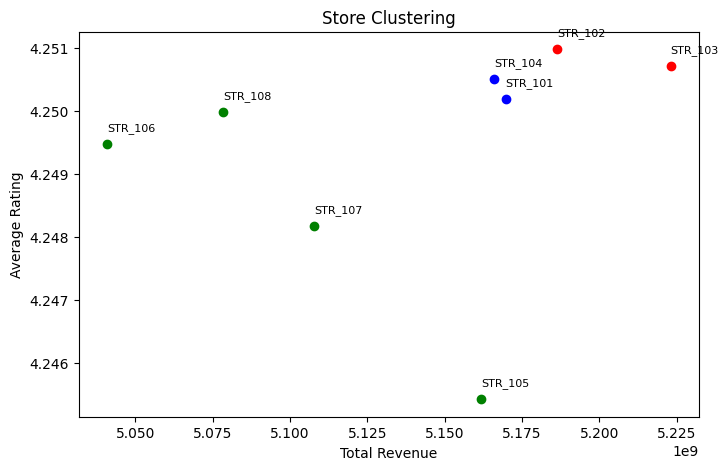

In [61]:
colors = {0: 'red', 1: 'green', 2: 'blue'}
plt.figure(figsize=(8,5))
for cluster in store_features['Cluster'].unique():
  subset = store_features[store_features['Cluster'] == cluster]
  plt.scatter(subset['total_revenue'], subset['avg_rating'], color=colors[cluster], label=f'Cluster {cluster}')
  for _, row in subset.iterrows():
    plt.annotate(row['Store_ID'], (row['total_revenue'], row['avg_rating']), textcoords='offset points', xytext=(0,10), fontsize=8)

plt.xlabel('Total Revenue')
plt.ylabel('Average Rating')
plt.title('Store Clustering')

*dashboard*

In [63]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.line(monthly,
              x='Month_Name',
              y='Revenue',
              color='Year',
              title='Monthly Revenue Trend',
              labels={'Revenue': 'Revenue (Rps)', 'Month_Name': 'Month', 'Year': 'Year'})
fig.show()